# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Heart Disease** dari UCI Machine Learning Repository.

- **Sumber**: [UCI ML Repository](https://archive.ics.uci.edu/dataset/45/heart+disease)
- **Jumlah data**: 303 sampel
- **Jumlah fitur**: 13 fitur input + 1 target (num/diagnosis)
- **Tipe problem**: Binary Classification
- **Tujuan**: Memprediksi kehadiran penyakit jantung (0 = tidak ada, 1 = ada)

Fitur-fitur:
- age, sex, cp (chest pain type), trestbps (resting blood pressure)
- chol (serum cholesterol), fbs (fasting blood sugar), restecg
- thalach (max heart rate), exang (exercise induced angina)
- oldpeak, slope, ca (number of major vessels), thal


# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka yang dibutuhkan untuk analisis data dan pembangunan model machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("Library berhasil diimpor!")


Library berhasil diimpor!


# **3. Memuat Dataset**

Memuat dataset Heart Disease dari file CSV.
Dataset ini tidak memiliki header, sehingga kita definisikan nama kolom secara manual.


In [2]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("../heart-disease.csv", names=columns, na_values="?")

print("Shape dataset:", df.shape)
print("\nKolom dataset:")
print(df.columns.tolist())
print("\n5 Baris Pertama:")
df.head()


Shape dataset: (303, 14)

Kolom dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

5 Baris Pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan EDA untuk memahami karakteristik dataset.


## 4.1 Informasi Umum Dataset


In [3]:
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nTipe data:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Duplikat: {df.duplicated().sum()} baris")


INFORMASI DATASET
Jumlah baris: 303
Jumlah kolom: 14

Tipe data:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6
Duplikat: 0 baris


## 4.2 Statistik Deskriptif


In [4]:
df.describe().round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


## 4.3 Distribusi Target

Target asli memiliki nilai 0-4, di mana 0 = tidak ada penyakit jantung dan 1-4 = ada penyakit jantung.
Kita ubah menjadi binary: 0 vs 1.


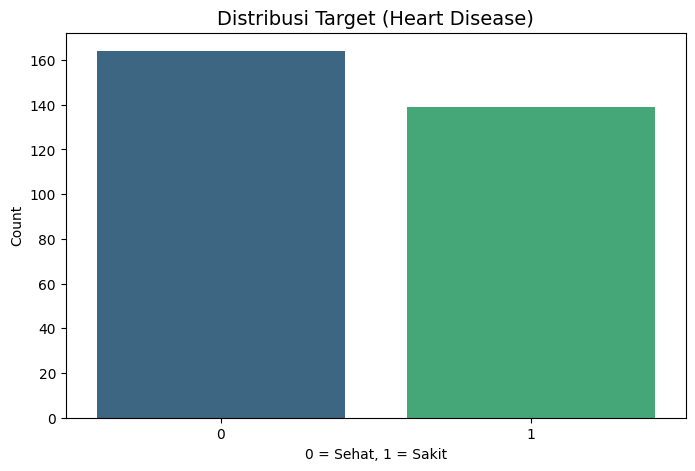


Distribusi kelas target:
target
0    164
1    139
Name: count, dtype: int64


In [5]:
# Ubah target menjadi binary (0 = sehat, 1 = sakit)
df["target"] = (df["target"] > 0).astype(int)

plt.figure(figsize=(8, 5))
sns.countplot(x="target", data=df, palette="viridis")
plt.title("Distribusi Target (Heart Disease)", fontsize=14)
plt.xlabel("0 = Sehat, 1 = Sakit")
plt.ylabel("Count")
plt.show()

print("\nDistribusi kelas target:")
print(df["target"].value_counts())


## 4.4 Korelasi Antar Fitur


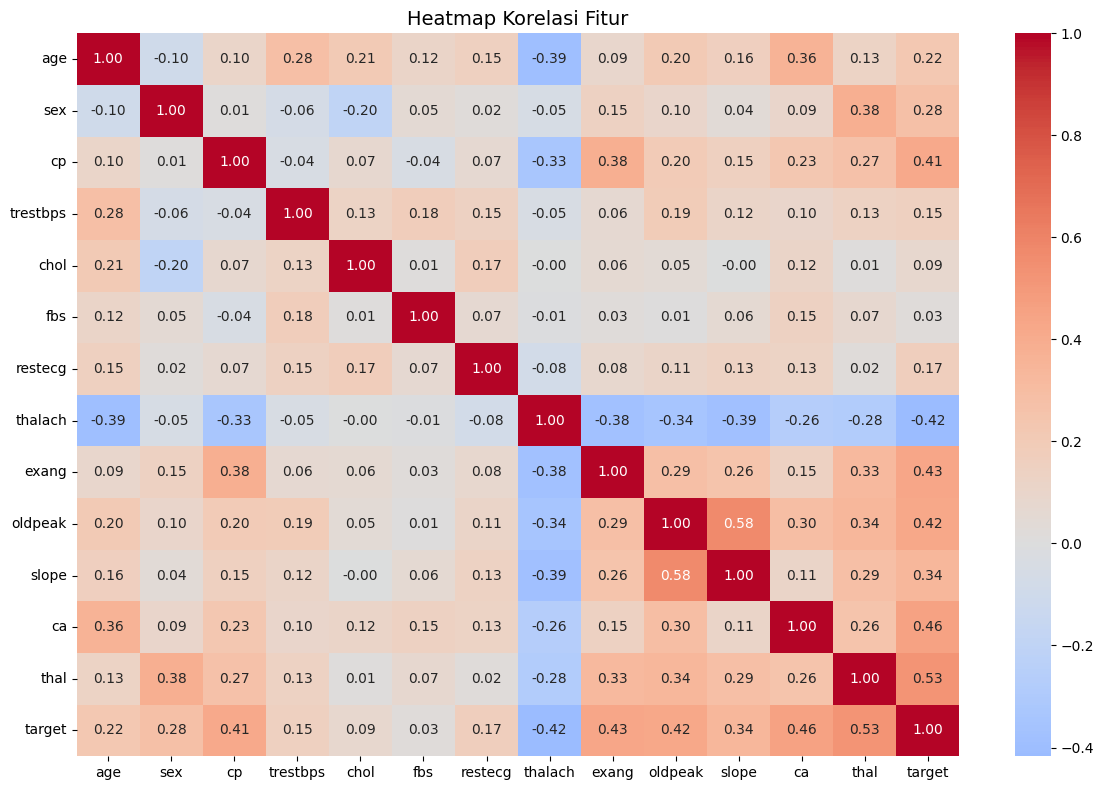

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur", fontsize=14)
plt.tight_layout()
plt.show()


## 4.5 Distribusi Fitur


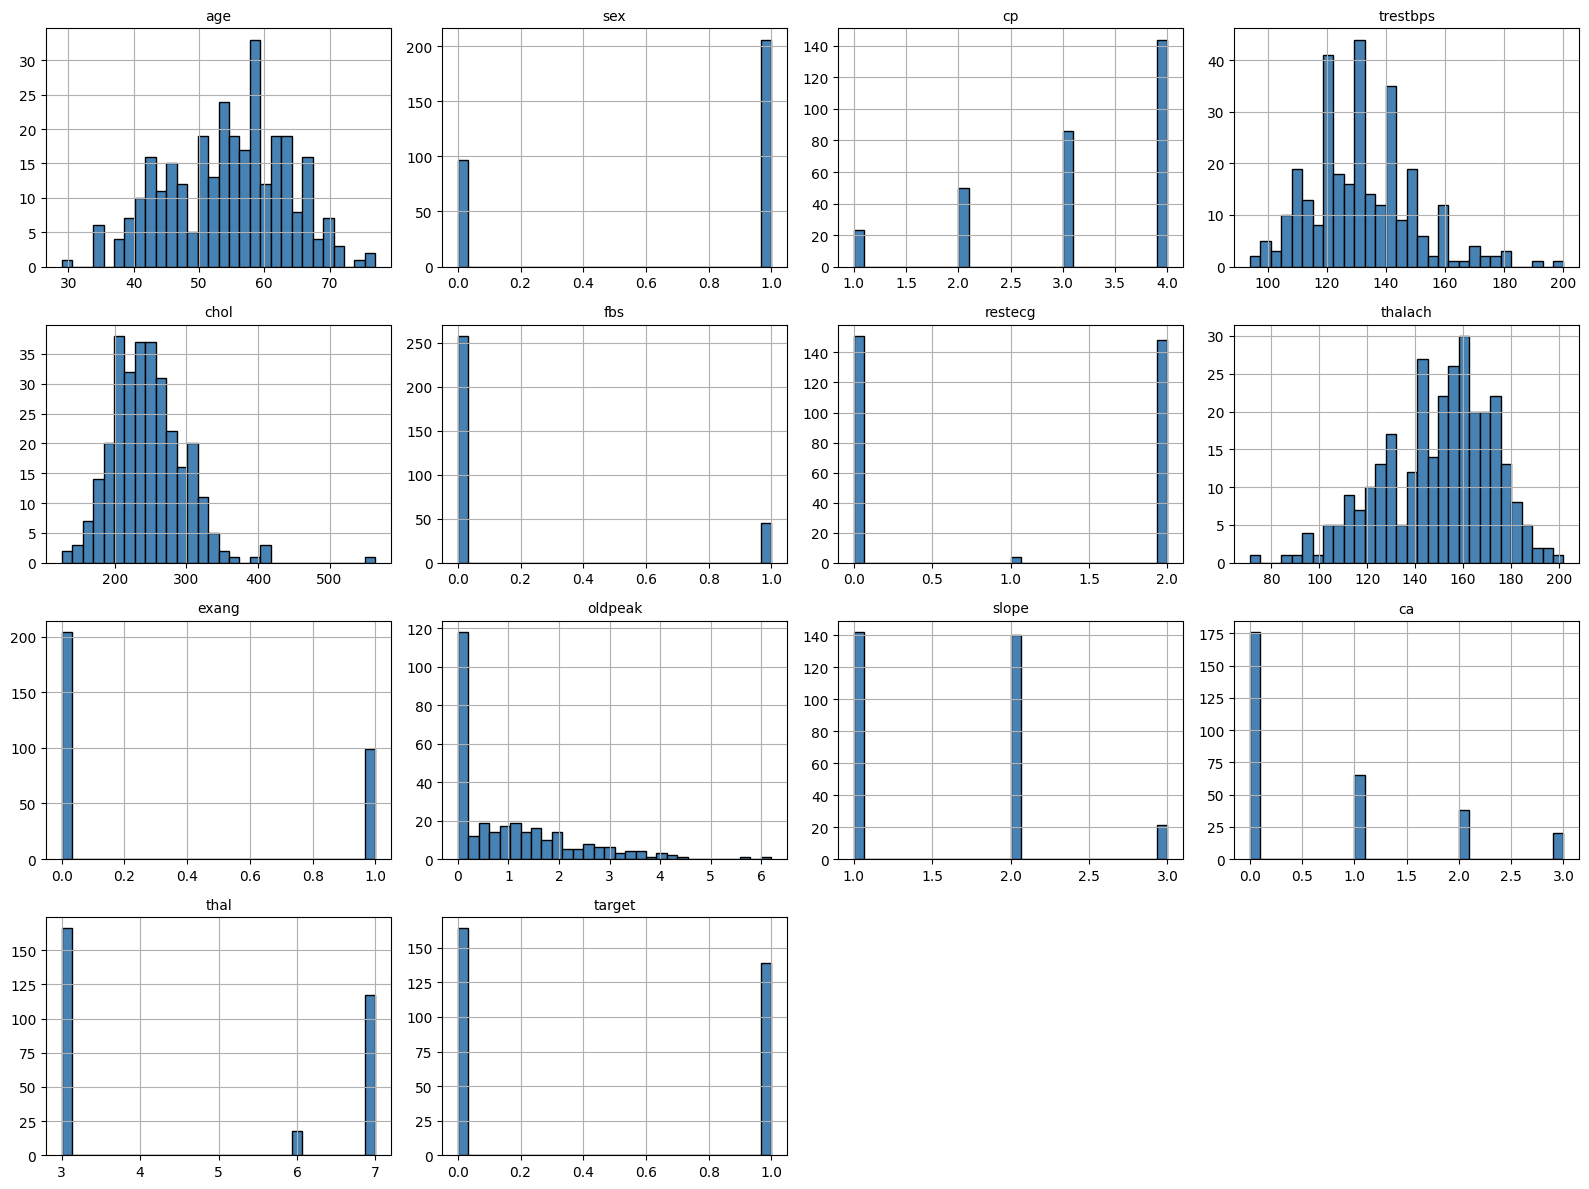

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(df.columns):
    ax = axes[i // 4, i % 4]
    df[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col, fontsize=10)
for j in range(len(df.columns), 16):
    axes[j // 4, j % 4].set_visible(False)
plt.tight_layout()
plt.show()


## 4.6 Boxplot untuk Deteksi Outlier


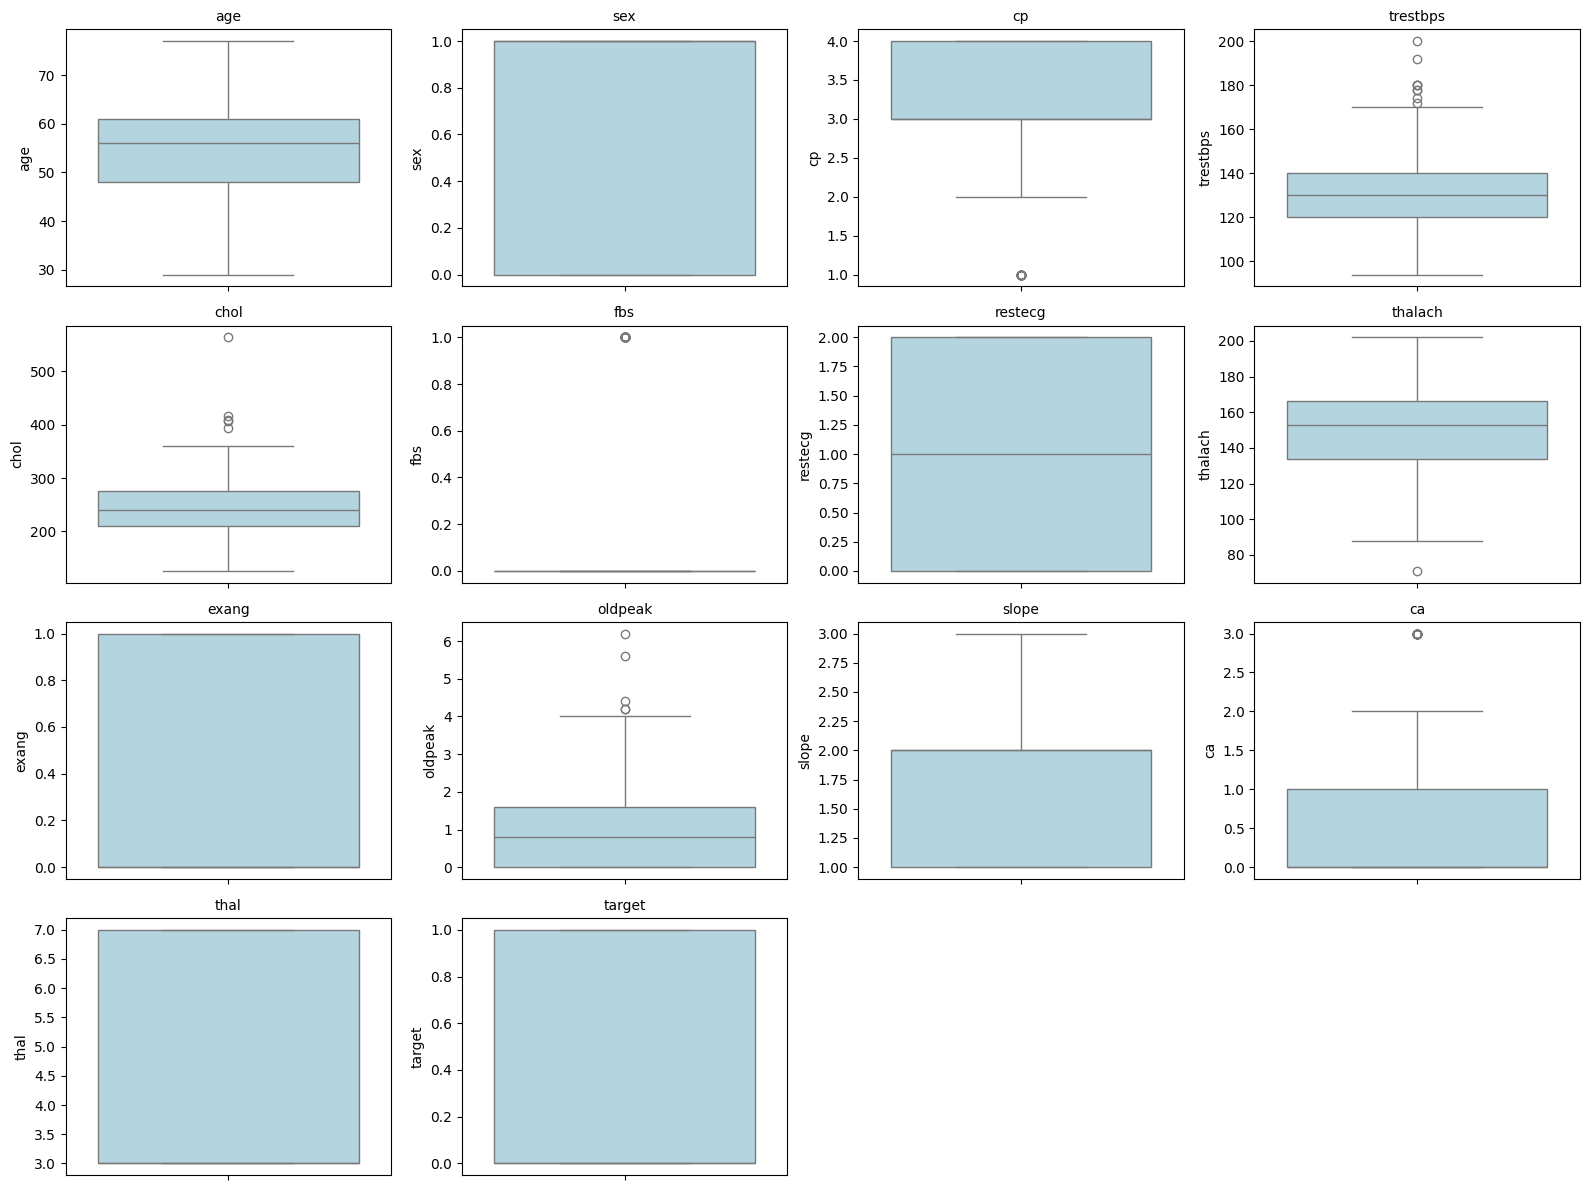

In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 4, i % 4]
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(col, fontsize=10)
for j in range(len(numerical_cols), 16):
    axes[j // 4, j % 4].set_visible(False)
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data agar siap digunakan untuk melatih model.


## 5.1 Menangani Missing Values


In [9]:
print(f"Missing values sebelum:\n{df.isnull().sum()}")
print(f"\nTotal: {df.isnull().sum().sum()}")

# Isi missing values dengan median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f"\nMissing values sesudah: {df.isnull().sum().sum()}")


Missing values sebelum:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total: 6

Missing values sesudah: 6


## 5.2 Menghapus Data Duplikat


In [10]:
print(f"Jumlah duplikat sebelum: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Jumlah duplikat sesudah: {df.duplicated().sum()}")
print(f"Shape setelah hapus duplikat: {df.shape}")


Jumlah duplikat sebelum: 0
Jumlah duplikat sesudah: 0
Shape setelah hapus duplikat: (303, 14)


## 5.3 Memisahkan Fitur dan Target


In [11]:
X = df.drop("target", axis=1)
y = df["target"]

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")


Shape fitur (X): (303, 13)
Shape target (y): (303,)


## 5.4 Split Data (Train & Test)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (242, 13)
X_test: (61, 13)
y_train: (242,)
y_test: (61,)


## 5.5 Normalisasi Fitur (StandardScaler)


In [13]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Statistik X_train setelah scaling:")
print(X_train_scaled.describe().round(2))


Statistik X_train setelah scaling:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  242.00  242.00  242.00    242.00  242.00  242.00   242.00   242.00   
mean    -0.00    0.00    0.00     -0.00    0.00   -0.00     0.00    -0.00   
std      1.00    1.00    1.00      1.00    1.00    1.00     1.00     1.00   
min     -2.85   -1.46   -2.21     -2.10   -2.35   -0.41    -0.98    -3.49   
25%     -0.73   -1.46   -0.93     -0.62   -0.72   -0.41    -0.98    -0.68   
50%      0.16    0.68   -0.16     -0.05   -0.10   -0.41    -0.98     0.16   
75%      0.72    0.68    0.87      0.51    0.53   -0.41     1.02     0.71   
max      2.50    0.68    0.87      3.93    5.96    2.43     1.02     2.30   

        exang  oldpeak   slope      ca    thal  
count  242.00   242.00  242.00  241.00  241.00  
mean     0.00     0.00   -0.00   -0.00   -0.00  
std      1.00     1.00    1.00    1.00    1.00  
min     -0.70    -0.89   -0.96   -0.69   -0.88  
25%     -0.70    -0.89   -

## 5.6 Menyimpan Dataset Hasil Preprocessing


In [14]:
train_data = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

train_data.to_csv("heart_disease_preprocessing_train.csv", index=False)
test_data.to_csv("heart_disease_preprocessing_test.csv", index=False)

print("Dataset preprocessing berhasil disimpan!")
print(f"Train: {train_data.shape}")
print(f"Test: {test_data.shape}")
print(f"NaN check - Train: {train_data.isnull().sum().sum()}, Test: {test_data.isnull().sum().sum()}")


Dataset preprocessing berhasil disimpan!
Train: (242, 14)
Test: (61, 14)
NaN check - Train: 2, Test: 4
